# L2A validation: remote-sensing reflectance against AERONET-OC

This notebook evaluates the remote-sensing reflectance $R_{rs}$ retrieved from Sentinel-2 by GRS
(L2A products) against the measurements of an [AERONET-OC](https://aeronet.gsfc.nasa.gov) station,
here `RdP-EsNM` in the turbid waters of the Río de la Plata estuary (Argentina).

Two in situ data sets are used:

- the hyperspectral $R_{rs}$ reconstructed from the AERONET-OC multispectral data by the InvRrs method
  (350-1100 nm), interpolated to the Sentinel-2 wavelengths;
- the multispectral AERONET-OC level 1.5 $R_{rs}$ (`Rrs_Lwn`, 400-709 nm), shown on the spectra.

**Workflow**

1. load the AERONET-OC time series of the station;
2. build the multi-temporal GRS L2A datacube over a box centred on the station
   ({class}`grstbx.L2grs`) and compute, for each image, the statistics of the valid pixels within the
   box;
3. pair each image with the in situ spectra acquired within a given time lag and compute the
   agreement statistics per band and for all the bands.

The same workflow against the HYPERNETS radiometer is detailed in the tutorial
*L2A validation: remote-sensing reflectance against HYPERNETS*.

```{note}
The GRS images and the AERONET-OC data are not distributed with grstbx: the notebook is rendered with
the outputs of its last run. Set the paths of the configuration cell to run it on your own data.
```

## Libraries and configuration

In [1]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # activate the rio accessor
import matplotlib as mpl
import matplotlib.pyplot as plt

import grstbx

opj = os.path.join
warnings.filterwarnings('ignore', message='The specified chunks separate')

plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'stix',
                     'font.size': 13, 'axes.labelsize': 14,
                     'figure.dpi': 80})

print(f'grstbx: {grstbx.__version__}')

grstbx: 2.3.0


In [2]:
# ---- in situ data
SITE = 'RdP-EsNM'
AERONET_INFO = '/DATA/AERONET/info_aeronet_oc_v15_location.csv'    # location and S2 tile of the sites
INVRRS_DIR = '/DATA/AERONET/OCv3_invRrs/data'                       # hyperspectral InvRrs Rrs
AERONET_FILE = f'/DATA/AERONET/netcdf/OCv3/lev15/{SITE}_OCv3.lev15.nc'   # multispectral AERONET-OC

# ---- satellite data
L2A_DIR = '/data/satellite/Sentinel-2/subset/L2A'
DATACUBE_DIR = '/data/satellite/Sentinel-2/subset/datacube'   # cache of the datacube
START_DATE, END_DATE = '2018-01-01', '2024-12-31'
BOX_SIZE = 500           # side of the square box centred on the station (m);
                         # delete the cached datacube when changing it
WL_MAX = 900

# ---- matchup criteria
MAX_LAG = np.timedelta64(1, 'h')   # maximum time lag between satellite and in situ data
MIN_VALID_FRACTION = 0.5           # minimum proportion of valid pixels within the box

## AERONET-OC data

The location of the station and the Sentinel-2 tile that covers it are read from the AERONET-OC
site table.

In [3]:
site = pd.read_csv(AERONET_INFO, index_col=0).loc[SITE]
tile, clon, clat = site.s2_tile, site.longitude, site.latitude
print(f'{SITE}: lon={clon}, lat={clat}, tile {tile}, data from {site.start_date} to {site.end_date}')

invrrs = xr.open_mfdataset(opj(INVRRS_DIR, f'{SITE}_OCv3_lev15', '*.nc')).load().sortby('time')
aeronet = xr.open_dataset(AERONET_FILE).load()
invrrs

RdP-EsNM: lon=-57.8959, lat=-34.818, tile 21HVB, data from 2023-03-04 to 2025-02-07


<xarray.Dataset> Size: 8MB
Dimensions:  (time: 5209, wl: 200)
Coordinates:
  * time     (time) datetime64[ns] 42kB 2023-03-04T10:40:40 ... 2024-08-28T17...
  * wl       (wl) float64 2kB 350.0 353.8 357.5 ... 1.092e+03 1.096e+03 1.1e+03
Data variables:
    Rrs      (time, wl) float64 8MB nan nan nan ... 0.0007156 0.0006642
Attributes:
    description:  InvRrs generated hyperspectral Rrs from multispectral AERON...

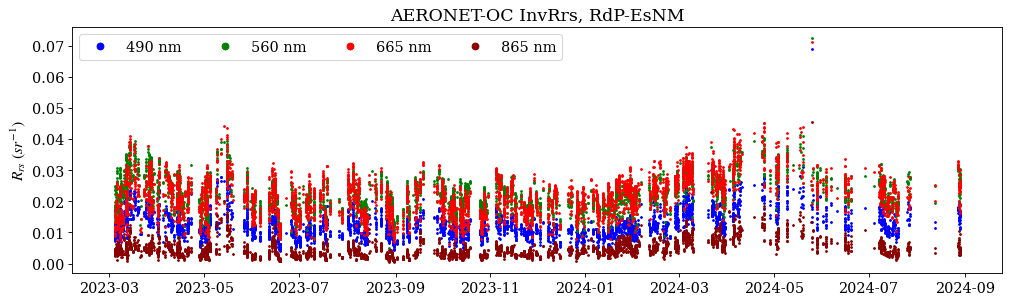

In [4]:
fig, ax = plt.subplots(figsize=(15, 4))
for wl, color in zip([490, 560, 665, 865], ['blue', 'green', 'red', 'darkred']):
    ax.plot(invrrs.time.values, invrrs.Rrs.sel(wl=wl, method='nearest').values, 'o', ms=1.5, c=color,
            label=f'{wl} nm')
ax.set_ylabel(r'$R_{rs}\ (sr^{-1})$')
ax.legend(ncol=4, markerscale=4)
ax.set_title(f'AERONET-OC InvRrs, {SITE}');

## Satellite datacube

The L2A products are stored as `L2A_DIR/<tile>/YYYY/MM/DD/<product>`. The datacube is cropped to a
square box centred on the station ({meth}`grstbx.SpatioTemp.wktbox`) and cached as a netCDF file.
For each image, the proportion of pixels raised for each flag is added as `flag_<name>` variables
(see {meth}`grstbx.L2grs.get_flag_stats`).

In [5]:
def list_grs_products(rootdir, tile, pattern='*'):
    '''
    List the GRS products stored as ``rootdir/tile/YYYY/MM/DD/<product>``.

    The product names follow the ESA convention
    ``<satellite>_<level>_<time>_<baseline>_<orbit>_<tile>_<processing time>``.

    :return: pandas.DataFrame indexed (and sorted) by acquisition time, with the path of each product
    '''
    paths = sorted(glob.glob(opj(rootdir, tile, '*', '*', '*', pattern)))
    if not paths:
        raise FileNotFoundError(f'no product found in {opj(rootdir, tile)}')
    names = pd.Series([os.path.basename(p) for p in paths])
    products = names.str.split('_', expand=True).iloc[:, :7]
    products.columns = ['satellite', 'level', 'time', 'baseline', 'orbit', 'tile', 'processing_time']
    products['time'] = pd.to_datetime(products['time'])
    products['path'] = paths
    return products.set_index('time').sort_index()


products = list_grs_products(L2A_DIR, tile)
files = products[START_DATE:END_DATE].path.values
print(f'{len(files)} L2A products from {products.index[0]:%Y-%m-%d} to {products.index[-1]:%Y-%m-%d}')

box = grstbx.SpatioTemp().wktbox(clon, clat, width=BOX_SIZE, height=BOX_SIZE)
bbox = gpd.GeoDataFrame(geometry=gpd.GeoSeries.from_wkt([box]), crs=4326)

os.makedirs(DATACUBE_DIR, exist_ok=True)
dc_path = opj(DATACUBE_DIR, f'{SITE}_{START_DATE}_{END_DATE}_L2A_matchup.nc')
if not os.path.exists(dc_path):
    dc = grstbx.L2grs(files)
    dc.get_l2a_datacube(subset=bbox)
    dc.datacube.to_netcdf(dc_path)

dcube = xr.open_dataset(dc_path, decode_coords='all').drop_duplicates('time').load()
dcube

43 L2A products from 2023-03-11 to 2024-01-30


<xarray.Dataset> Size: 6MB
Dimensions:                          (time: 43, y: 25, x: 25, wl: 11)
Coordinates:
  * time                             (time) datetime64[ns] 344B 2023-03-11T13...
  * y                                (y) float64 200B 6.147e+06 ... 6.147e+06
  * x                                (x) float64 200B 4.178e+05 ... 4.183e+05
  * wl                               (wl) int64 88B 443 490 560 ... 1610 2190
    spatial_ref                      int64 8B 0
Data variables: (12/22)
    aot550                           (time, y, x) float64 215kB 0.281 ... 0.303
    Rrs                              (time, wl, y, x) float64 2MB 0.01223 ......
    BRDFg                            (time, wl, y, x) float64 2MB 0.00071 ......
    vza                              (time, y, x) float64 215kB 9.87 ... 9.86
    sza                              (time, y, x) float64 215kB 43.22 ... 34.05
    raa                              (time, y, x) float64 215kB 57.9 ... 41.37
    ...                               ...
    flag_thin_cirrus                 (time) float64 344B 0.0 0.0 0.0 ... 0.0 0.0
    flag_opac_cirrus                 (time) float64 344B 0.0 0.0 0.0 ... 0.0 0.0
    flag_high_swir                   (time) float64 344B 0.0 0.0 0.0 ... 0.0 0.0
    flag_surfwater_land              (time) float64 344B 0.0 0.0 0.0 ... 0.0 0.0
    flag_surfwater_water             (time) float64 344B 1.0 1.0 1.0 ... 1.0 1.0
    flag_surfwater_cloud_and_shadow  (time) float64 344B 0.0 0.0 0.0 ... 0.0 0.0
Attributes: (12/74)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/21HVB...
    product_name:                        S2A_MSIL1C_20230311T133831_N0509_R12...
    product_filename:                    S2A_MSIL1C_20230311T133831_N0509_R12...
    ...                                  ...
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/Dropbox/Dropbox/work/gi...
    water_vapor_transmittance_file:      /home/harmel/Dropbox/Dropbox/work/gi...
    metadata_profile:                    datacube
    start_date:                          2023-03-11T13:38:31.000000000
    stop_date:                           2024-01-30T13:38:29.000000000

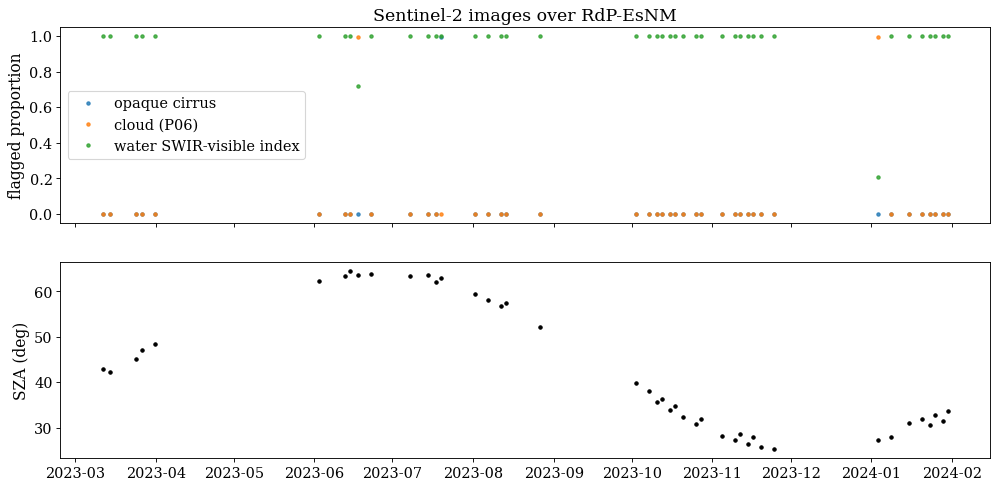

In [6]:
fig, axs = plt.subplots(nrows=2, figsize=(15, 7), sharex=True)
for flag, label in [('flag_opac_cirrus', 'opaque cirrus'), ('flag_cloud_p06', 'cloud (P06)'),
                    ('flag_water_swir_visible_index', 'water SWIR-visible index')]:
    axs[0].plot(dcube.time.values, dcube[flag].values, 'o', ms=3, alpha=0.8, label=label)
axs[0].set_ylabel('flagged proportion')
axs[0].legend()
axs[1].plot(dcube.time.values, dcube.mean_solar_zenith_angle.values, 'o', ms=3, c='k')
axs[1].set_ylabel('SZA (deg)')
axs[0].set_title(f'Sentinel-2 images over {SITE}');

Statistics of the valid pixels (`mask == 0`) within the box, for each image:

In [7]:
# 'central_wavelength' (actual band centres of S2A / S2B) is not needed here
Rrs = dcube.Rrs.sel(wl=slice(0, WL_MAX)).where(dcube.mask == 0).drop_vars('central_wavelength', errors='ignore')
npix = dcube.sizes['x'] * dcube.sizes['y']
with warnings.catch_warnings():  # images without any valid pixel
    warnings.simplefilter('ignore', RuntimeWarning)
    sat = xr.Dataset({'Rrs_median': Rrs.median(['x', 'y']),
                      'Rrs_q25': Rrs.quantile(0.25, ['x', 'y']).drop_vars('quantile'),
                      'Rrs_q75': Rrs.quantile(0.75, ['x', 'y']).drop_vars('quantile'),
                      'Rrs_mean': Rrs.mean(['x', 'y']),
                      'Rrs_std': Rrs.std(['x', 'y']),
                      'valid_fraction': Rrs.isel(wl=0).count(['x', 'y']) / npix,
                      'sza': dcube.sza.mean(['x', 'y']),
                      'aot550': dcube.aot550.mean(['x', 'y'])})
sat = sat.where(sat.valid_fraction > 0, drop=True)
print(f'{sat.sizes["time"]} images with valid pixels')

41 images with valid pixels


## Matchups

For each image, the InvRrs spectra acquired within `MAX_LAG` are summarized by their median,
quartiles and standard deviation, and interpolated to the nominal wavelengths of Sentinel-2.

In [8]:
def insitu_statistics(time):
    window = invrrs.sel(time=slice(time - MAX_LAG, time + MAX_LAG))
    if window.sizes['time'] == 0:
        return None
    Rrs = window.Rrs
    with warnings.catch_warnings():  # wavelengths without valid in situ data
        warnings.simplefilter('ignore', RuntimeWarning)
        stats = {'n_spectra': window.sizes['time'],
                 'isRrs_median': Rrs.median('time'),
                 'isRrs_q25': Rrs.quantile(0.25, 'time').drop_vars('quantile'),
                 'isRrs_q75': Rrs.quantile(0.75, 'time').drop_vars('quantile'),
                 'isRrs_std': Rrs.std('time')}
    return xr.Dataset(stats).expand_dims(time=[time])


insitu_stats = [insitu_statistics(time) for time in sat.time.values]
insitu_stats = xr.concat([s for s in insitu_stats if s is not None], dim='time')
insitu_stats = insitu_stats.interp(wl=sat.wl.values)

matchup = xr.merge([sat, insitu_stats], join='inner')
matchup['good'] = matchup.valid_fraction >= MIN_VALID_FRACTION
print(f'{matchup.sizes["time"]} matchups, {int(matchup.good.sum())} with more than '
      f'{MIN_VALID_FRACTION:.0%} of valid pixels')

matchup.to_netcdf(opj(DATACUBE_DIR, f'{SITE}_{START_DATE}_{END_DATE}_L2A_matchup_stats.nc'))
matchup

33 matchups, 32 with more than 50% of valid pixels


<xarray.Dataset> Size: 23kB
Dimensions:         (time: 33, wl: 9)
Coordinates:
  * time            (time) datetime64[ns] 264B 2023-03-11T13:38:31 ... 2024-0...
  * wl              (wl) int64 72B 443 490 560 665 705 740 783 842 865
    spatial_ref     int64 8B 0
Data variables: (12/14)
    Rrs_median      (time, wl) float64 2kB 0.01224 0.01853 ... 0.00749 0.00423
    Rrs_q25         (time, wl) float64 2kB 0.01171 0.01784 ... 0.00653 0.00363
    Rrs_q75         (time, wl) float64 2kB 0.01237 0.01875 ... 0.00779 0.00451
    Rrs_mean        (time, wl) float64 2kB 0.012 0.01823 ... 0.007155 0.004057
    Rrs_std         (time, wl) float64 2kB 0.0005713 0.0007451 ... 0.0006314
    valid_fraction  (time) float64 264B 1.0 1.0 1.0 0.9968 ... 1.0 1.0 1.0 1.0
    ...              ...
    n_spectra       (time) int64 264B 12 6 2 10 1 4 4 4 12 ... 3 8 10 5 11 3 3 7
    isRrs_median    (time, wl) float64 2kB 0.01269 0.01891 ... 0.006673 0.005605
    isRrs_q25       (time, wl) float64 2kB 0.01128 0.01674 ... 0.006468 0.005437
    isRrs_q75       (time, wl) float64 2kB 0.01311 0.01964 ... 0.00676 0.005689
    isRrs_std       (time, wl) float64 2kB 0.001618 0.002406 ... 0.0001916
    good            (time) bool 33B True True True True ... True True True True

Spectra of each matchup: AERONET-OC InvRrs (blue lines) and multispectral `Rrs_Lwn` (green dots),
Sentinel-2 median (black) and inter-quartile range (grey) within the box, with an RGB thumbnail of
the box. The titles of the matchups discarded for too few valid pixels are in red.

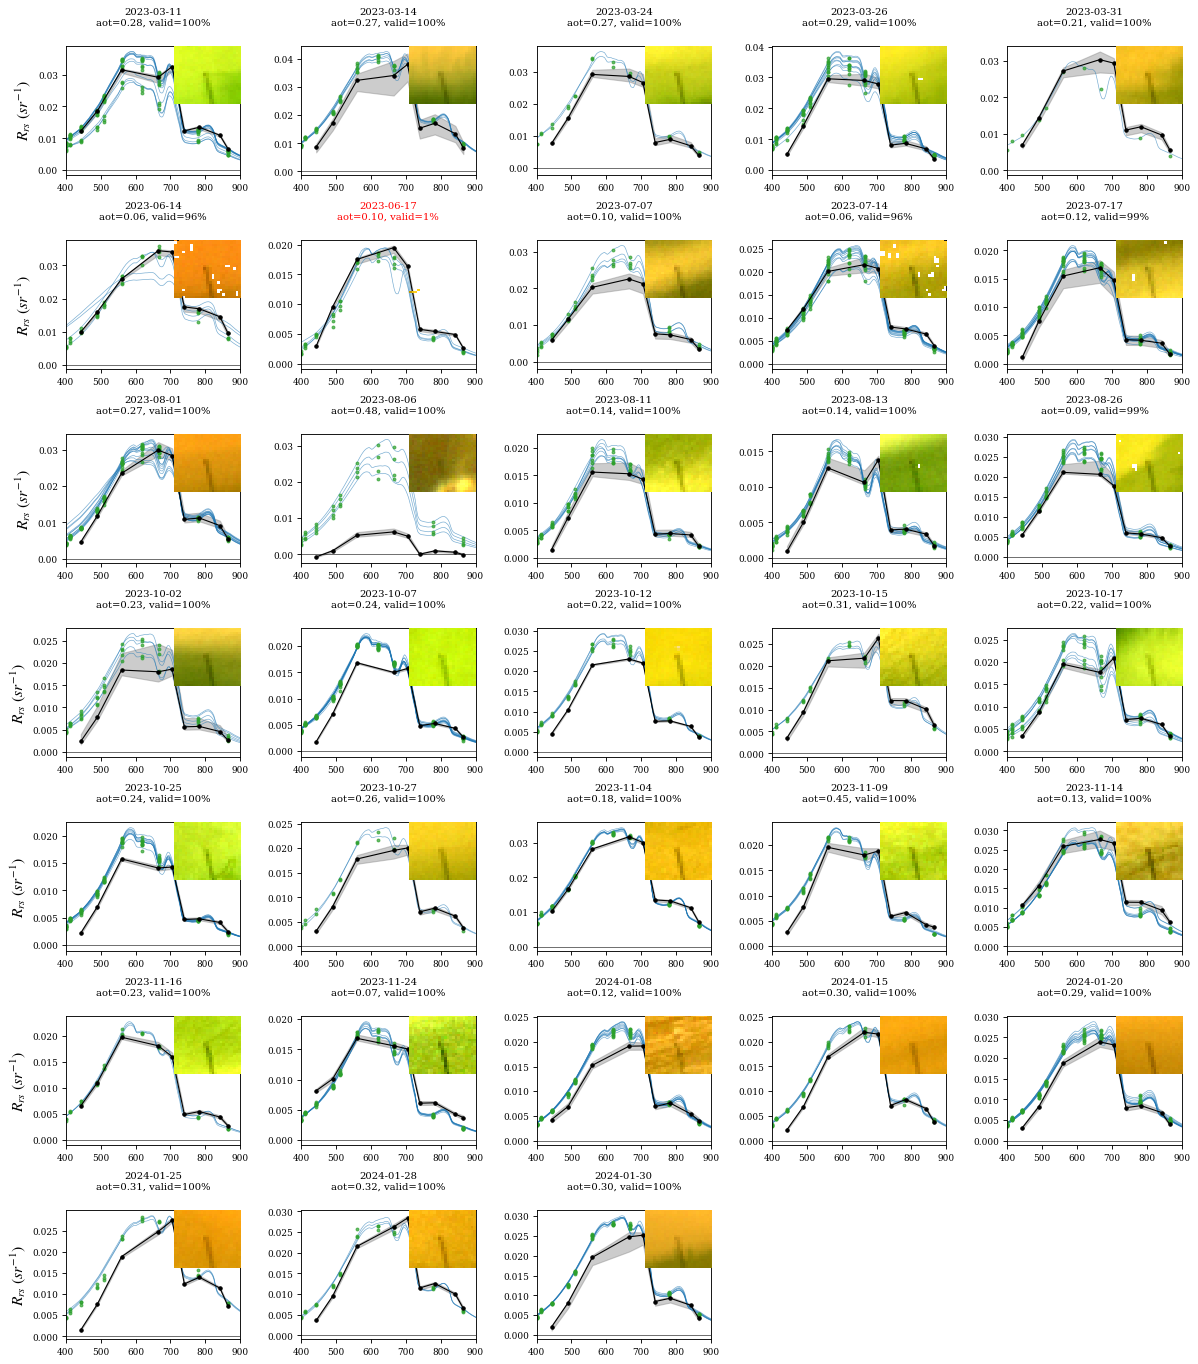

In [9]:
ncols = 5
nrows = int(np.ceil(matchup.sizes['time'] / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 3.), squeeze=False)
fig.subplots_adjust(hspace=0.5, wspace=0.35)
for ax in axs.flat:
    ax.set_axis_off()
for ax, time in zip(axs.flat, matchup.time.values):
    m = matchup.sel(time=time)
    window = invrrs.sel(time=slice(time - MAX_LAG, time + MAX_LAG))
    multi = aeronet.sel(time=slice(time - MAX_LAG, time + MAX_LAG))
    ax.set_axis_on()
    ax.plot(window.wl, window.Rrs.T, c='tab:blue', lw=0.6, alpha=0.6)
    ax.plot(multi.wl, multi.Rrs_Lwn.T, 'o', c='tab:green', ms=2.5, alpha=0.7)
    ax.fill_between(m.wl, m.Rrs_q25, m.Rrs_q75, color='grey', alpha=0.4)
    ax.plot(m.wl, m.Rrs_median, 'o-', c='k', ms=3, lw=1)
    ax.axhline(0, c='k', lw=0.5)
    ax.set_xlim(400, 900)
    title = f"{pd.Timestamp(time):%Y-%m-%d}\naot={float(m.aot550):.2f}, valid={float(m.valid_fraction):.0%}"
    ax.set_title(title, fontsize=9, color='k' if bool(m.good) else 'red')
    ax.tick_params(labelsize=8)

    inset = ax.inset_axes([0.62, 0.55, 0.38, 0.45])
    rgb = dcube.Rrs.sel(time=time, wl=[665, 560, 490]).where(dcube.mask.sel(time=time) == 0)
    rgb.plot.imshow(ax=inset, rgb='wl', robust=True)
    inset.set_axis_off()
    inset.set_title('')
for ax in axs[:, 0]:
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})$')

## Agreement statistics

In [10]:
def matchup_metrics(x, y):
    '''
    Agreement statistics between in situ (``x``) and satellite (``y``) values.

    - slope, intercept and Pearson's r of the linear regression of y vs x,
    - rmse and bias (mean of y - x), in the units of the data,
    - mape: mean absolute percentage error (%),
    - eps: median symmetric accuracy (%) and beta: signed symmetric percentage bias (%)
      (Morley et al., 2018; Eqs. 8-9 in Pahlevan et al., 2020), computed on the
      strictly positive pairs.
    '''
    from scipy import stats

    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    regr = stats.linregress(x, y)
    pos = (x > 0) & (y > 0)
    log_ratio = np.log10(y[pos] / x[pos])
    med = np.median(log_ratio)
    return {'N': len(x),
            'slope': regr.slope,
            'intercept': regr.intercept,
            'r': regr.rvalue,
            'rmse': np.sqrt(np.mean((y - x) ** 2)),
            'bias': np.mean(y - x),
            'mape': 100 * np.mean(np.abs(y - x) / np.abs(x)),
            'eps': 100 * (10 ** np.median(np.abs(log_ratio)) - 1),
            'beta': 100 * np.sign(med) * (10 ** np.abs(med) - 1)}


def plot_matchup(ax, x, y, vmin, vmax, fmt='.4f', xerr=None, yerr=None, **kwargs):
    '''Scatter plot of y vs x with error bars, 1:1 and regression lines, and the agreement statistics.'''
    m = matchup_metrics(x, y)
    if xerr is not None or yerr is not None:
        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none', color='grey', lw=0.6, capsize=2, zorder=1)
    sc = ax.scatter(x, y, zorder=2, **kwargs)
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    grstbx.Plotting.set_layout(ax)          # square axes and 1:1 line
    ax.axline((0, m['intercept']), slope=m['slope'], ls='--', lw=1.2, c='grey')
    text = '\n'.join([f"$y = {m['slope']:.2f}x {m['intercept']:+{fmt}}$",
                      f"$r = {m['r']:.3f}$",
                      f"$rmse = {m['rmse']:{fmt}}$",
                      f"$bias = {m['bias']:{fmt}}$",
                      f"$\\epsilon = {m['eps']:.1f}\\%$",
                      f"$\\beta = {m['beta']:+.1f}\\%$",
                      f"$N = {m['N']}$"])
    ax.text(0.97, 0.03, text, fontsize=10, ha='right', va='bottom', transform=ax.transAxes)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.minorticks_on()
    return sc, m

Per band:

,N,slope,intercept,r,rmse,bias,mape,eps,beta
443,32.0,0.8285,-0.0020,0.6625,0.0042,-0.0034,47.9906,97.3579,-97.3579
490,32.0,0.9082,-0.0015,0.8006,0.0036,-0.0027,23.2470,31.6117,-31.6117
560,32.0,0.9702,-0.0020,0.8513,0.0040,-0.0026,12.1818,12.5639,-12.5639
665,32.0,0.9730,0.0003,0.8061,0.0040,-0.0003,10.1547,5.9933,-0.6120
705,32.0,1.0082,-0.0001,0.8736,0.0034,0.0001,8.6793,4.1254,1.2471
740,32.0,0.9050,0.0001,0.8742,0.0019,-0.0007,14.9856,10.3364,-7.2734
783,32.0,0.9897,0.0001,0.9046,0.0016,0.0000,13.4860,9.8549,1.3982
842,32.0,1.1514,0.0006,0.9044,0.0020,0.0014,32.9999,32.6190,29.4743
865,32.0,0.8413,0.0004,0.8648,0.0012,-0.0004,19.4421,16.1502,-5.6938


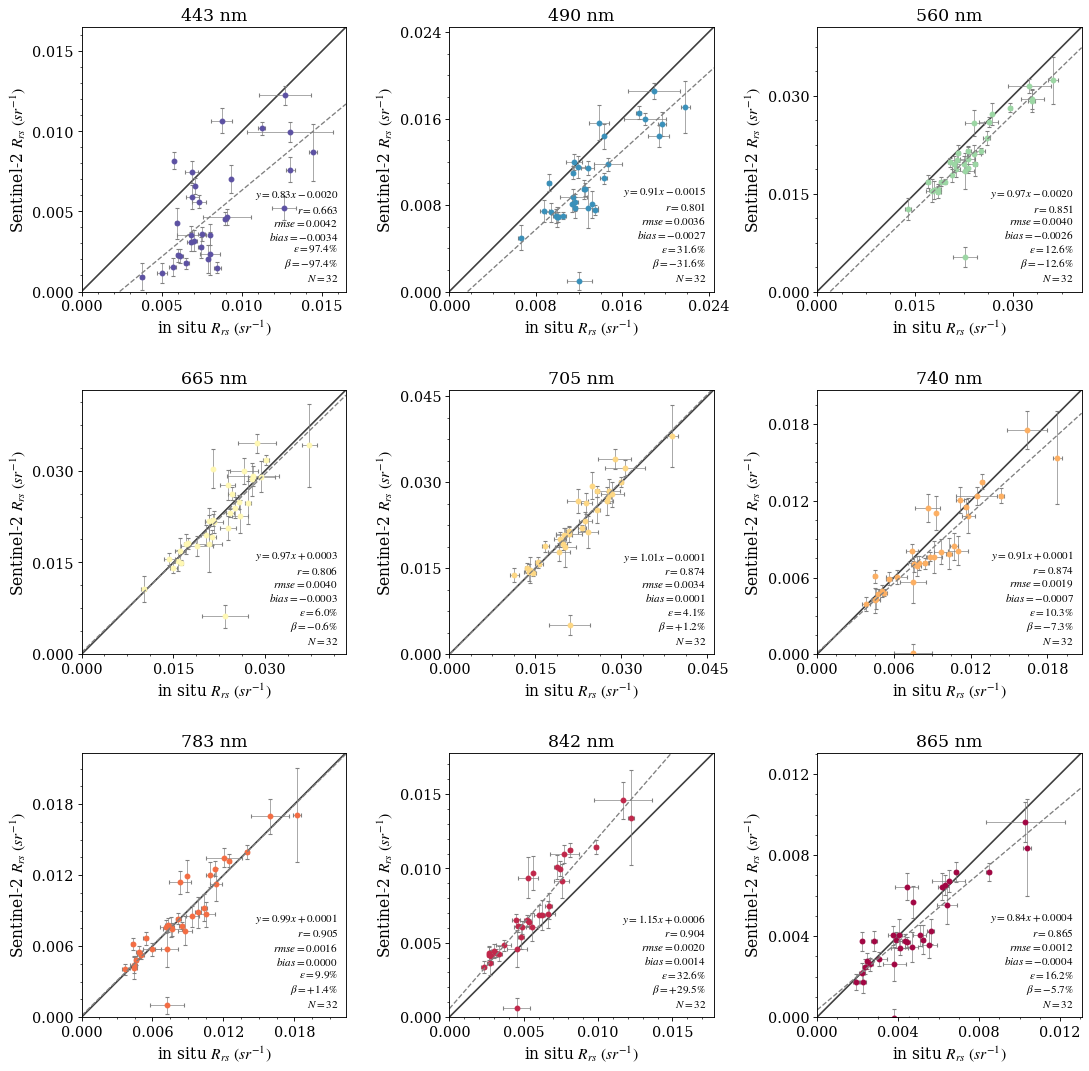

In [11]:
good = matchup.where(matchup.good, drop=True)
cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=440, vmax=870)

wls = good.wl.values
ncols = 3
nrows = int(np.ceil(len(wls) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 4.6, nrows * 4.6), squeeze=False)
for ax in axs.flat:
    ax.set_axis_off()
metrics = {}
for ax, wl in zip(axs.flat, wls):
    m = good.sel(wl=wl)
    ax.set_axis_on()
    vmax_band = 1.1 * float(max(m.isRrs_q75.max(), m.Rrs_q75.max()))
    _, metrics[wl] = plot_matchup(ax, m.isRrs_median, m.Rrs_median, 0, vmax_band,
                                  xerr=m.isRrs_std, yerr=m.Rrs_std, color=cmap(norm(wl)), s=18)
    ax.set_title(f'{wl} nm')
    ax.set_xlabel(r'in situ $R_{rs}\ (sr^{-1})$')
    ax.set_ylabel(r'Sentinel-2 $R_{rs}\ (sr^{-1})$')
fig.tight_layout()

pd.DataFrame(metrics).T.round(4)

All bands:

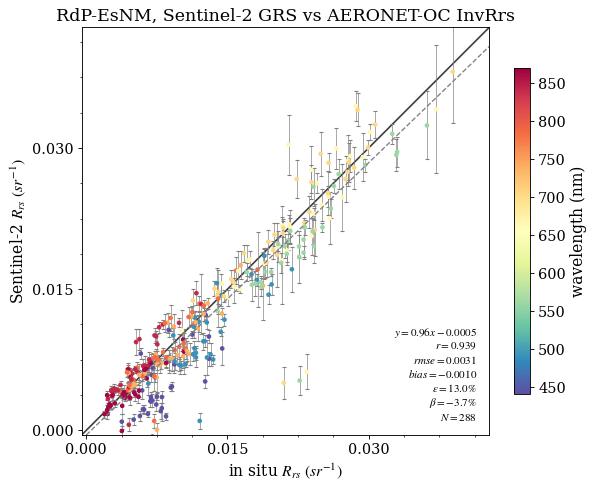

In [12]:
df = good[['Rrs_median', 'Rrs_std', 'isRrs_median']].to_dataframe().dropna().reset_index()
vmax = 1.1 * float(df[['Rrs_median', 'isRrs_median']].max().max())

fig, ax = plt.subplots(figsize=(7.5, 6), layout='constrained')
sc, _ = plot_matchup(ax, df.isRrs_median, df.Rrs_median, -0.0005, vmax, yerr=df.Rrs_std,
                     c=df.wl, cmap=cmap, norm=norm, s=10)
ax.set_xlabel(r'in situ $R_{rs}\ (sr^{-1})$')
ax.set_ylabel(r'Sentinel-2 $R_{rs}\ (sr^{-1})$')
ax.set_title(f'{SITE}, Sentinel-2 GRS vs AERONET-OC InvRrs')
fig.colorbar(sc, ax=ax, shrink=0.8, label='wavelength (nm)');

**Notes**

- The InvRrs spectra are linearly interpolated to the nominal Sentinel-2 wavelengths; a convolution
  with the spectral response functions of each band (S2A and S2B) would be more accurate.
- The InvRrs spectra beyond 709 nm (last AERONET-OC band) are extrapolated by the inversion: the
  agreement in the near infrared depends on this reconstruction.
- The `eps` and `beta` metrics are less sensitive to outliers than `rmse` and `bias`; they are
  computed in log space and expressed in %.

**References**

- Morley, S. K., Brito, T. V., & Welling, D. T. (2018). Measures of model performance based on the
  log accuracy ratio. *Space Weather*, 16, 69-88.
- Pahlevan, N., et al. (2020). Seamless retrievals of chlorophyll-a from Sentinel-2 (MSI) and
  Sentinel-3 (OLCI) in inland and coastal waters: a machine-learning approach. *Remote Sensing of
  Environment*, 240, 111604.
- Zibordi, G., et al. (2009). AERONET-OC: a network for the validation of ocean color primary
  products. *Journal of Atmospheric and Oceanic Technology*, 26(8), 1634-1651.